In [1]:
import numpy as np

## Hypertension model

In [2]:
from impute_hyper import schedule_hypertension_probability

## load BMI and age matrix 

In [3]:
from Age_BMI_loading import (
    age_matrix_vec,
    bmi_matrix_ls,
    age_dict,
    bmi_samples_dict
)


In [4]:
bmi_samples_dict[0][18].shape

(922, 1)

## save matrix to hypertension folder 

In [5]:
hypertension_status_dict = {}
N = 8

for group in range(N):
    hypertension_status_dict[group] = {}
    for age in age_dict[group]:
        bmi_samples = bmi_samples_dict[group][age]  # shape: (n_samples, n_ages)
        n_samples, n_ages = bmi_samples.shape
        # Create an age matrix with shape (n_samples, n_ages)
        age_mat = np.tile(np.arange(18, age + 1), (n_samples, 1))
        idx = group

        # Compute hypertension probability matrix
        hypertension_prob_matrix = schedule_hypertension_probability(age_mat, idx, bmi_samples)
        rand_matrix = np.random.rand(*bmi_samples.shape)
        hypertension_matrix = (rand_matrix < hypertension_prob_matrix)
        hypertension_matrix = np.maximum.accumulate(hypertension_matrix, axis=1)

        hypertension_status_dict[group][age] = np.max(hypertension_matrix, axis=1)  # vector of 0, 1

In [6]:
# for first column, find positions of age a, 
# hypertension_status_dict[0][40]

hyper_mat_list = []
for i in range(8):
    hypertension_status = np.zeros((age_matrix_vec[i].shape[0], age_matrix_vec[i].shape[1] ))  
    for age, status_vec in hypertension_status_dict[i].items():
        # Find positions where the first column of age_matrix_vec[i] equals 'age'
        positions = np.where(age_matrix_vec[i][:, 0] == age)[0]
        # Get the hypertension status vector for this age group
        hypertension_status[positions, 0] = status_vec
    
    # deal with hypertension status 
    bmi_mat = bmi_matrix_ls[i]
    age_mat = age_matrix_vec[i]

    hypertension_prob_matrix = schedule_hypertension_probability(age_mat, i, bmi_mat)
    rand_matrix = np.random.rand(*age_mat.shape)
    hypertension_matrix = (rand_matrix < hypertension_prob_matrix)

    # count the first vector 
    hypertension_status[:, 1:] = hypertension_matrix[:,1:]
    hypertension_status = np.maximum.accumulate(hypertension_status, axis=1)
    hyper_mat_list.append(hypertension_status)

In [7]:
# hypertension mapping

import numpy as np

# Define age groups
age_groups = [(18, 29), (30, 39), (40, 49), (50, 59), (60, 69), (70, 74)]

# Initialize matrices
total_counts_mat = np.zeros((8, 6))  # Number of people in each age group
hypertension_counts_mat = np.zeros((8, 6))  # Number of hypertensive people in each age group
prevalence_ls = []  # Prevalence for each ethnicity-gender group

# Iterate over each ethnicity-gender group
for idx in range(8):
    last_col_ages = age_matrix_vec[idx][:, -2]  # Last column of age matrix
    last_col_hyper = hyper_mat_list[idx][:, -2]  # Last column of hypertension matrix

    # Compute overall prevalence for idx
    mask_all = (last_col_ages >= 18) & (last_col_ages <= 74)
    total_people = np.sum(mask_all)
    hypertensive_people = np.sum(last_col_hyper[mask_all])
    
    # Store prevalence (avoid division by zero)
    prevalence_ls.append(hypertensive_people / total_people if total_people > 0 else 0)
    prevalence_ls = prevalence_ls[:6] # except others
    # Assign people to age groups and count
    for group_idx, (lower, upper) in enumerate(age_groups):
        mask = (last_col_ages >= lower) & (last_col_ages <= upper)
        
        total_counts_mat[idx, group_idx] = np.sum(mask)  # Total people in age group
        hypertension_counts_mat[idx, group_idx] = np.sum(last_col_hyper[mask])  # Hypertensive people in age group

# Compute age-specific prevalence
age_specific_prevalence = np.divide(
    hypertension_counts_mat.sum(axis=0),
    total_counts_mat.sum(axis=0),
    out=np.zeros_like(hypertension_counts_mat.sum(axis=0)),  # Avoid division by zero
    where=total_counts_mat.sum(axis=0) > 0
)

# Concatenate the final results
final_result = np.concatenate([prevalence_ls, age_specific_prevalence])

# Print the final result
print(final_result)


[0.45164183 0.30565319 0.43579514 0.36831849 0.37952981 0.20786913
 0.05676511 0.13601819 0.29393393 0.53242904 0.69840873 0.8171113 ]


In [8]:
## save to data hyper_matrix 


In [9]:
targeting_list = np.array([44.6, 30.3, 44.1, 37, 39.6, 21.8, 8.1, 17.4, 31.9, 53.7, 64.3, 76.8]) / 100
print(targeting_list)

[0.446 0.303 0.441 0.37  0.396 0.218 0.081 0.174 0.319 0.537 0.643 0.768]


## save results to hyper_matrix folder

In [10]:
import os

# Create the directory if it doesn't exist
save_dir = "../data/hyper_matrix"
os.makedirs(save_dir, exist_ok=True)

# Save each matrix in hyper_mat_list
for i, hyper_mat in enumerate(hyper_mat_list):
    save_path = os.path.join(save_dir, f"hyper_mat_{i}.npy")
    np.save(save_path, hyper_mat)
    print(f"Saved: {save_path}")

# Load the hyper_mat_0.npy file
hyper_mat_0 = np.load("../data/hyper_matrix/hyper_mat_0.npy")
# Print the shape of the loaded matrix
print("Shape of hyper_mat_0:", hyper_mat_0.shape)
# Assert the shape of hyper_mat_0
assert hyper_mat_0.shape == (88417, 34), f"Expected shape (88417, 34), but got {hyper_mat_0.shape}"

Saved: ../data/hyper_matrix/hyper_mat_0.npy
Saved: ../data/hyper_matrix/hyper_mat_1.npy
Saved: ../data/hyper_matrix/hyper_mat_2.npy
Saved: ../data/hyper_matrix/hyper_mat_3.npy
Saved: ../data/hyper_matrix/hyper_mat_4.npy
Saved: ../data/hyper_matrix/hyper_mat_5.npy
Saved: ../data/hyper_matrix/hyper_mat_6.npy
Saved: ../data/hyper_matrix/hyper_mat_7.npy
Shape of hyper_mat_0: (88417, 34)


## plots

[0.45164183 0.30565319 0.43579514 0.36831849 0.37952981 0.20786913
 0.05676511 0.13601819 0.29393393 0.53242904 0.69840873 0.8171113 ]


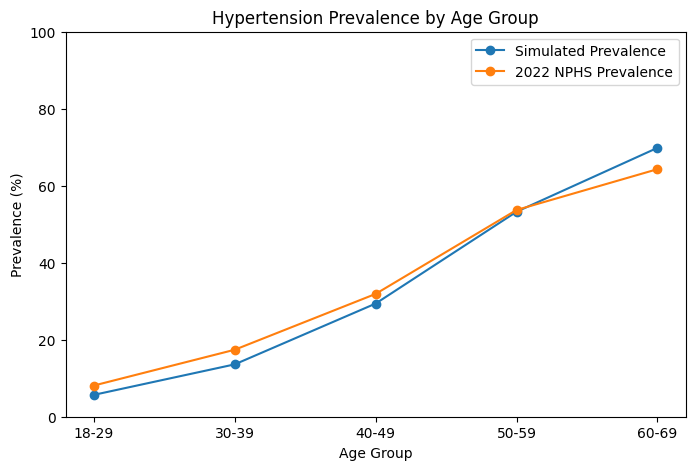

In [11]:
import matplotlib.pyplot as plt
import numpy as np


age_labels = ["18-29", "30-39", "40-49", "50-59", "60-69", "70-74"]

final_result = np.concatenate([prevalence_ls, age_specific_prevalence])

# Print the final result
print(final_result)

# Extracting relevant slices
simulated_prevalence = final_result[6:11] * 100
nphs_prevalence = targeting_list[6:11] * 100
age_labels = age_labels[:-1] 
# Plotting
plt.figure(figsize=(8, 5))

plt.plot(age_labels, simulated_prevalence, marker='o', linestyle='-', label="Simulated Prevalence", markersize=6)
plt.plot(age_labels, nphs_prevalence, marker='o', linestyle='-', label="2022 NPHS Prevalence", markersize=6)
plt.ylim(0,100)
plt.xlabel("Age Group")
plt.ylabel("Prevalence (%)")
plt.title("Hypertension Prevalence by Age Group")
plt.legend()

plt.savefig("plots/hypertension_prevalence_by_age_group.png", dpi=300, bbox_inches='tight')

plt.show()